# ScamRadar+ — Data Preparation Notebook

**Project:** ScamRadar+ (E8-P9 build)
**CRISP-DM phase:** Data Preparation — final deliverable

This notebook consumes the output of the Data Understanding notebook
(`data/interim/raw_unified.parquet`) and derives the final prepared corpus
by invoking the production pipeline scripts in order. Every pipeline stage
is **cache-aware**: if its output already exists on disk, the stage is
skipped and the cached artifact is reused. Set `FORCE_REBUILD = True` in
Section 0 to re-run every stage from scratch.

After the pipeline orchestration completes, the notebook stores the final
prepared corpus in a relational SQLite database, exposes retrieval
functions, renders an ERD, and runs the Final EDA.

**Chain from Data Understanding →**
`data/interim/raw_unified.parquet` (from DU notebook)
**→ this notebook →**
`data/interim/e7_p1_features_e8p9.parquet` (derived)
**→**
`data/final_db/scamradar_e8p9.db` (final DP deliverable)

## 0. Setup

Paths, imports, and cache-aware helpers.

- `FORCE_REBUILD` — set to `True` to re-run every pipeline stage even when
  its output is already cached on disk.
- `SCAMRADAR2_ROOT` — the standalone location of the upstream data-pipeline
  project that owns the `acquire → clean → audit → split` stages. The
  scamradar2 code was imported into `data_pipeline/src/scamradar/` in this
  repo but is invoked from its original working directory so the pipeline's
  relative paths resolve correctly.

In [1]:
from __future__ import annotations

import hashlib
import os
import shutil
import sqlite3
import subprocess
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from scipy import stats

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 160)
plt.rcParams['figure.figsize'] = (10, 5)

# ─── Cache behaviour ──────────────────────────────────────────────────
FORCE_REBUILD = False   # flip to True to re-run every pipeline stage

# ─── Repo root discovery ──────────────────────────────────────────────
NB_DIR = Path.cwd()
REPO_ROOT = NB_DIR
for _ in range(6):
    if (REPO_ROOT / 'models' / 'e7_p1_variants').exists() and (REPO_ROOT / 'api').exists():
        break
    REPO_ROOT = REPO_ROOT.parent
else:
    raise RuntimeError(f'Could not locate ScamRadar+ repo root from {NB_DIR}')

# ─── Paths ────────────────────────────────────────────────────────────
# Scamradar2 (upstream pipeline) — configurable via SCAMRADAR2_ROOT env var.
SCAMRADAR2_ROOT = Path(os.environ.get(
    'SCAMRADAR2_ROOT', str(REPO_ROOT / 'data_pipeline')
)).resolve()
SR2_CANONICAL = SCAMRADAR2_ROOT / 'data' / 'raw'      / 'canonical.parquet'
SR2_CLEAN     = SCAMRADAR2_ROOT / 'data' / 'interim'  / 'clean.parquet'
SR2_APPROVAL  = SCAMRADAR2_ROOT / 'data' / 'APPROVAL.json'
SR2_TRAIN     = SCAMRADAR2_ROOT / 'data' / 'processed' / 'train.parquet'
SR2_VAL       = SCAMRADAR2_ROOT / 'data' / 'processed' / 'val.parquet'
SR2_TEST      = SCAMRADAR2_ROOT / 'data' / 'processed' / 'test.parquet'
SR2_EXT       = SCAMRADAR2_ROOT / 'data' / 'external_benchmark' / 'benchmark.parquet'

# E7-P1 feature-engineered E5 base + synthetic + E8 stages
E7_P1_FEATURES = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features.parquet'
E8P2_SYNTH     = REPO_ROOT / 'data' / 'synthetic_legit' / 'e8p2' / 'dataset.parquet'
E8P6_SYNTH     = REPO_ROOT / 'data' / 'synthetic_legit' / 'e8p6' / 'dataset.parquet'
E8P8_SCAM      = REPO_ROOT / 'data' / 'synthetic_scam'  / 'e8p8' / 'scam_dataset.parquet'
E8P8_PAIRS     = REPO_ROOT / 'data' / 'synthetic_scam'  / 'e8p8' / 'legit_pairs_dataset.parquet'
E8P2_MERGED    = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features_e8p2.parquet'
E8P3_CLEANED   = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features_e8p3.parquet'
E8P5_CLEANED   = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features_e8p5.parquet'
E8P6_MERGED    = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features_e8p6.parquet'
FINAL_PARQUET  = REPO_ROOT / 'data' / 'interim' / 'e7_p1_features_e8p9.parquet'

# DP deliverable (this notebook's output)
DB_DIR  = REPO_ROOT / 'data' / 'final_db'
DB_PATH = DB_DIR / 'scamradar_e8p9.db'
DB_DIR.mkdir(parents=True, exist_ok=True)

print(f'Repo root         : {REPO_ROOT}')
print(f'SCAMRADAR2_ROOT   : {SCAMRADAR2_ROOT}   (exists={SCAMRADAR2_ROOT.exists()})')
print(f'DU input          : {SR2_CANONICAL}   (exists={SR2_CANONICAL.exists()})')
print(f'Final DP output   : {DB_PATH}')
print(f'FORCE_REBUILD     : {FORCE_REBUILD}')

Repo root         : /Users/ameer/Downloads/ScamRadar
SCAMRADAR2_ROOT   : /Users/ameer/Downloads/ScamRadar/data_pipeline   (exists=True)
DU input          : /Users/ameer/Downloads/ScamRadar/data_pipeline/data/raw/canonical.parquet   (exists=True)
Final DP output   : /Users/ameer/Downloads/ScamRadar/data/final_db/scamradar_e8p9.db
FORCE_REBUILD     : False


In [2]:
# ─── Cache-aware helper ──────────────────────────────────────────────

def cached_step(name: str, outputs: list[Path] | Path, build_fn):
    """Run build_fn only if any of the expected outputs is missing (or if
    FORCE_REBUILD is set). Prints a clear status line either way."""
    outs = outputs if isinstance(outputs, list) else [outputs]
    missing = [o for o in outs if not o.exists()]

    print(f'── {name} ──')
    if not FORCE_REBUILD and not missing:
        for o in outs:
            print(f'  ✓ cached  {o}   ({o.stat().st_size / 1e6:.1f} MB)')
        return

    if FORCE_REBUILD:
        print(f'  ⟳ FORCE_REBUILD — running from scratch')
    else:
        print(f'  → building (missing: {[str(m) for m in missing]})')

    t0 = time.time()
    build_fn()
    dt = time.time() - t0

    still_missing = [o for o in outs if not o.exists()]
    if still_missing:
        raise RuntimeError(f'Build failed; still missing: {still_missing}')
    for o in outs:
        print(f'  ✓ built   {o}   ({o.stat().st_size / 1e6:.1f} MB)')
    print(f'  time: {dt:.1f}s')


# ─── Subprocess wrappers ──────────────────────────────────────────────

PY = sys.executable   # use the same interpreter this notebook is running under


def run_scamradar(subcommand: list[str], extra_env: dict | None = None):
    """Invoke the scamradar2 CLI from its own working directory so its
    relative paths (data/raw, data/interim, data/processed) resolve."""
    env = os.environ.copy()
    env['PYTHONPATH'] = str(SCAMRADAR2_ROOT / 'src')
    if extra_env:
        env.update(extra_env)
    subprocess.run(
        [PY, '-m', 'scamradar', *subcommand],
        cwd=str(SCAMRADAR2_ROOT),
        env=env, check=True,
    )


def run_repo_script(script_rel: str):
    """Invoke a script inside this repo (scripts/data_prep/*, etc.)."""
    subprocess.run(
        [PY, script_rel],
        cwd=str(REPO_ROOT),
        check=True,
    )


print('Helpers ready.')

Helpers ready.


## 1. Load the canonical artifact from Data Understanding

The DU notebook orchestrated `scamradar acquire` and produced
`SCAMRADAR2_ROOT/data/raw/canonical.parquet` — every real source normalised
into one canonical-schema table. That file is the input to this notebook
**and** the input the production pipeline already expects, so there is no
staging or copy step.


In [3]:
if not SR2_CANONICAL.exists():
    raise FileNotFoundError(
        f'Expected DU artifact at {SR2_CANONICAL}. '
        f'Run notebooks/data_understanding.ipynb first to produce it '
        f'(that notebook invokes `scamradar acquire`, which writes to this path).'
    )

raw_unified = pd.read_parquet(SR2_CANONICAL)
print(f'Loaded {SR2_CANONICAL}')
print(f'  rows    : {len(raw_unified):,}')
print(f'  columns : {list(raw_unified.columns)}')
print(f'  sources : {raw_unified.source.nunique()} distinct')
print(f'  labels  : {raw_unified.label.value_counts().to_dict()}')


Loaded /Users/ameer/Downloads/ScamRadar/data_pipeline/data/raw/canonical.parquet
  rows    : 279,230
  columns : ['sample_id', 'text', 'label', 'category', 'source', 'license', 'is_synthetic', 'era', 'platform', 'acquired_at']
  sources : 13 distinct
  labels  : {0: 222236, 1: 56994}


> **Data Labeling — Not Applicable.** All 13 real sources arrive pre-labelled by their publishers (`label ∈ {0, 1}` set by the source dataset). Synthetic rows are labelled at generation time by the E8-P2/P6/P8 scripts. No manual or semi-automatic labelling is performed by this project.


## 2. Data cleaning — `scamradar clean`

The `clean` stage performs:
- Unicode NFKC normalization + URL/digit/whitespace canonicalization.
- Exact-hash deduplication.
- Near-duplicate clustering via MinHash (128 permutations over char 5-gram
  shingles) + LSH (16 bands × 8 rows) + union-find.

Output: `SCAMRADAR2_ROOT/data/interim/clean.parquet` (adds `cluster_id` and
`exact_hash` columns), plus a `reports/data_quality.json` audit summary.

In [4]:
def build_clean():
    run_scamradar(['clean'])


cached_step('scamradar clean', SR2_CLEAN, build_clean)

# Show the current cleaning report if present.
report_path = SCAMRADAR2_ROOT / 'reports' / 'data_quality.json'
if report_path.exists():
    import json
    r = json.loads(report_path.read_text())
    print()
    print(f'  clean.parquet rows              : {r.get("rows_after", "n/a")}')
    print(f'  exact duplicates removed        : {r.get("exact_duplicates_removed", "n/a")}')
    print(f'  rows in near-dup clusters       : {r.get("rows_in_near_dup_clusters", "n/a")}')

── scamradar clean ──
  → building (missing: ['/Users/ameer/Downloads/ScamRadar/data_pipeline/data/interim/clean.parquet'])


[clean] 279230 -> 251299 rows | exact dups removed: 27901 | near-dup clusters: 15201
  ✓ built   /Users/ameer/Downloads/ScamRadar/data_pipeline/data/interim/clean.parquet   (118.5 MB)
  time: 87.8s

  clean.parquet rows              : n/a
  exact duplicates removed        : 27901
  rows in near-dup clusters       : 69658


## 3. Dataset audit + approval gate

The scamradar2 pipeline requires a human-in-the-loop approval before
`split`. In production this is a manual review of the audit report. For a
re-execution of an already-approved corpus, we auto-approve non-
interactively with `--yes` so the notebook is reproducible.

In [5]:
def build_approval():
    run_scamradar(['audit'])
    run_scamradar(['approve-dataset', '--yes', '--accept-red-flags',
                   '--approver', 'data_preparation_notebook'])


cached_step('audit + approve-dataset', SR2_APPROVAL, build_approval)

── audit + approve-dataset ──
  → building (missing: ['/Users/ameer/Downloads/ScamRadar/data_pipeline/data/APPROVAL.json'])


[audit] n=251299 scam=40202 legit=211097 scam_share=0.16 synthetic_share=0.0 era(overall) legacy=0.3572 modern=0.6428 unknown=0.0 clusters=196842 red_flags=3
  RED FLAG: taxonomy_missing[scam]: ['bec_ceo_fraud', 'marketplace_delivery_scam', 'romance_scam']
  RED FLAG: source_dominates_legit: multiwoz_v22=0.496 > 0.4
  RED FLAG: modern_scam_share_below_floor: 0.087 < 0.3
[audit] wrote reports/dataset_audit.json + .md  (dataset_hash=b0457eacdf0b…)
DATASET AUDIT — please review before approving
dataset_hash    : b0457eacdf0be0c4d6d8cd194b950e8db853dec3ba8a68ec0e642048c80f5c4d
total rows      : 251,299
  scam          : 40,202
  legit         : 211,097
scam share      : 0.16
synthetic share : 0.0
clusters        : 196,842 (largest = 0.0304 of dataset)
exact dups removed         : 27,901
rows in near-dup clusters  : 69,658
taxonomy covered           : ['advance_fee_fraud', 'email_phishing', 'ham_chat', 'ham_email', 'ham_sms', 'recruitment_scam', 'smishing']
taxonomy underrepresented  : []
t

In [6]:
# Evidence: contents of the audit report and the approval record
# produced by the previous step (scamradar audit + approve-dataset).
import json  # DP setup does not import json at module scope

def _report_path(name: str) -> Path | None:
    """Reports are written to <cwd>/reports/ when scamradar runs.
    If SCAMRADAR2_ROOT/data is a symlink to an external install,
    prior reports may live next to that install's data/ instead."""
    candidates = [SCAMRADAR2_ROOT / 'reports' / name,
                  (SCAMRADAR2_ROOT / 'data').resolve().parent / 'reports' / name]
    for c in candidates:
        if c.exists():
            return c
    return None

AUDIT_JSON    = _report_path('dataset_audit.json')
APPROVAL_JSON = SR2_APPROVAL

if AUDIT_JSON is not None:
    audit = json.loads(AUDIT_JSON.read_text())
    print(f'── Dataset audit report ──')
    print(f'  file           : {AUDIT_JSON}')
    print(f'  dataset_hash   : {audit.get("dataset_hash", "")[:16]}...')
    print(f'  totals         : {audit.get("totals")}')
    print(f'  class_balance  : {audit.get("class_balance")}')
    print(f'  dedup          : {audit.get("dedup")}')
    print(f'  red_flags      : {audit.get("red_flags")}')
    print()
else:
    print(f'⚠ dataset_audit.json not found in any candidate reports/ directory')

if APPROVAL_JSON.exists():
    approval = json.loads(APPROVAL_JSON.read_text())
    print(f'── Approval record ({APPROVAL_JSON.name}) ──')
    print(json.dumps(approval, indent=2))
else:
    print(f'⚠ approval record missing at {APPROVAL_JSON}')


── Dataset audit report ──
  file           : /Users/ameer/Downloads/ScamRadar/data_pipeline/reports/dataset_audit.json
  dataset_hash   : b0457eacdf0be0c4...
  totals         : {'n': 251299, 'n_scam': 40202, 'n_legit': 211097}
  class_balance  : {'scam_share': 0.16, 'legit_share': 0.84}
  dedup          : {'exact_duplicates_removed': 27901, 'rows_in_near_dup_clusters': 69658}
  red_flags      : ["taxonomy_missing[scam]: ['bec_ceo_fraud', 'marketplace_delivery_scam', 'romance_scam']", 'source_dominates_legit: multiwoz_v22=0.496 > 0.4', 'modern_scam_share_below_floor: 0.087 < 0.3']

── Approval record (APPROVAL.json) ──
{
  "approved_at": "2026-08-10T14:42:46.383820+00:00",
  "approver": "data_preparation_notebook",
  "dataset_hash": "b0457eacdf0be0c4d6d8cd194b950e8db853dec3ba8a68ec0e642048c80f5c4d",
  "audit_totals": {
    "n": 251299,
    "n_scam": 40202,
    "n_legit": 211097
  },
  "audit_class_balance": {
    "scam_share": 0.16,
    "legit_share": 0.84
  },
  "accepted_red_flags": 

## 4. Cluster-aware split — `scamradar split`

Produces four parquets: `train / val / test / external_benchmark`. The
split is stratified by class and grouped by `cluster_id` so no near-
duplicate ever appears on both sides of the split.

In [7]:
def build_split():
    run_scamradar(['split'])


cached_step('scamradar split',
            [SR2_TRAIN, SR2_VAL, SR2_TEST, SR2_EXT],
            build_split)

# `scripts/training/train_e7_p1.py` reads splits from
# `data_pipeline/data/processed/...`. When SCAMRADAR2_ROOT is the in-repo
# data_pipeline (default), that path is already correct — no symlink needed.
# When SCAMRADAR2_ROOT points elsewhere (external install), symlink
# data_pipeline/data → SCAMRADAR2_ROOT/data so the trainer finds the splits.
DATA_PIPELINE_DATA = REPO_ROOT / 'data_pipeline' / 'data'
if DATA_PIPELINE_DATA.resolve() == (SCAMRADAR2_ROOT / 'data').resolve():
    print(f'{DATA_PIPELINE_DATA} already resolves inside SCAMRADAR2_ROOT — nothing to do.')
elif not DATA_PIPELINE_DATA.exists():
    DATA_PIPELINE_DATA.symlink_to(SCAMRADAR2_ROOT / 'data')
    print(f'Symlinked {DATA_PIPELINE_DATA} → {SCAMRADAR2_ROOT / "data"}')
else:
    print(f'{DATA_PIPELINE_DATA} already exists — leaving as-is.')

── scamradar split ──
  → building (missing: ['/Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/train.parquet', '/Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/val.parquet', '/Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/test.parquet', '/Users/ameer/Downloads/ScamRadar/data_pipeline/data/external_benchmark/benchmark.parquet'])


[split] {"train": {"rows": 150781, "scam_share": 0.1728}, "val": {"rows": 37694, "scam_share": 0.1259}, "test": {"rows": 37695, "scam_share": 0.1286}, "external": {"rows": 25129, "scam_share": 0.1813}}
  ✓ built   /Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/train.parquet   (75.0 MB)
  ✓ built   /Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/val.parquet   (15.8 MB)
  ✓ built   /Users/ameer/Downloads/ScamRadar/data_pipeline/data/processed/test.parquet   (15.5 MB)
  ✓ built   /Users/ameer/Downloads/ScamRadar/data_pipeline/data/external_benchmark/benchmark.parquet   (13.1 MB)
  time: 10.1s
/Users/ameer/Downloads/ScamRadar/data_pipeline/data already resolves inside SCAMRADAR2_ROOT — nothing to do.


## 5. Feature engineering — 25 numerical features per row

For every row in the E5 base, compute the 25 numerical features implemented
in `src/_02_feature_engineering.py` (tone × 4, URL × 5, phrase × 3,
textstats × 13). Cached to `data/interim/e7_p1_features.parquet`.

The heavy work is done by `scripts.training.train_e7_p1.load_or_compute_features()`,
the same code path used at model training. Nothing is re-implemented here.

In [8]:
def build_e7_p1_features():
    # Import lazily so REPO_ROOT is on the path.
    if str(REPO_ROOT) not in sys.path:
        sys.path.insert(0, str(REPO_ROOT))
    from scripts.training.train_e7_p1 import load_or_compute_features
    load_or_compute_features()


cached_step('compute e7_p1 features on E5 base',
            E7_P1_FEATURES,
            build_e7_p1_features)

── compute e7_p1 features on E5 base ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features.parquet   (103.5 MB)


In [9]:
# Evidence: enumerate the numerical features created by E7-P1.
# Read the parquet schema only (no data read) so this is cheap.
import pyarrow.parquet as pq

_META = {'text', 'label', 'cluster_id', 'split', 'source', 'sample_id',
         'license', 'era', 'platform', 'category', 'is_synthetic', 'acquired_at'}

_all_cols = pq.read_schema(str(E7_P1_FEATURES)).names
_features = [c for c in _all_cols if c not in _META]

print(f'Engineered features created by E7-P1: {len(_features)}')
print(f'Artifact: {E7_P1_FEATURES}')
print()
for i, c in enumerate(_features, 1):
    print(f'  {i:2d}. {c}')


Engineered features created by E7-P1: 25
Artifact: /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features.parquet

   1. text_length
   2. word_count
   3. has_url
   4. url_count
   5. exclamation_count
   6. uppercase_ratio
   7. digit_ratio
   8. urgency_score
   9. tone_urgency
  10. tone_fear
  11. tone_reward
  12. tone_threat
  13. url_suspicious_tld
  14. url_suspicious_keyword
  15. url_has_ip
  16. scam_phrase_score
  17. sender_impersonation_score
  18. legit_phrase_score
  19. avg_word_length
  20. capitalized_word_count
  21. punctuation_density
  22. question_mark_count
  23. currency_symbol_count
  24. readability_score
  25. unique_word_ratio


## 6. Synthetic data generation

Three template-based generators produce the adversarial synthetic corpora:

- **E8-P2** — 1,978 near-boundary legitimate messages (shipping, OTP,
  banking notifications) targeting the E7-P1 false-positive region.
- **E8-P6** — 15,572 additional legitimate messages across 21 categories,
  65 brands.
- **E8-P8** — 14,669 synthetic scams + 1,109 paired-legit twins across
  weak-recall categories (investment, romance, emergency, refund,
  sextortion, threat, gift-card CEO, modern phishing).

Every generated message passes the rule-engine's validators before being
kept, so no synthetic legit row can contain a dangerous action pattern and
no synthetic scam is gibberish or unlabelled legit.

In [10]:
def build_e8p2_synth():  run_repo_script('scripts/data_prep/gen_e8p2_synthetic_legit.py')
def build_e8p6_synth():  run_repo_script('scripts/data_prep/gen_e8p6_synthetic_legit.py')
def build_e8p8_synth():  run_repo_script('scripts/data_prep/gen_e8p8_synthetic_scam.py')


cached_step('generate E8-P2 synthetic legit', E8P2_SYNTH, build_e8p2_synth)
cached_step('generate E8-P6 synthetic legit', E8P6_SYNTH, build_e8p6_synth)
cached_step('generate E8-P8 synthetic scam + pairs',
            [E8P8_SCAM, E8P8_PAIRS], build_e8p8_synth)

── generate E8-P2 synthetic legit ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/synthetic_legit/e8p2/dataset.parquet   (0.1 MB)
── generate E8-P6 synthetic legit ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/synthetic_legit/e8p6/dataset.parquet   (0.5 MB)
── generate E8-P8 synthetic scam + pairs ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/synthetic_scam/e8p8/scam_dataset.parquet   (0.4 MB)
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/synthetic_scam/e8p8/legit_pairs_dataset.parquet   (0.0 MB)


In [11]:
# Evidence: sample rows from each synthetic-generation artifact.
for label, path in [
    ('E8-P2 synthetic legit', E8P2_SYNTH),
    ('E8-P6 synthetic legit', E8P6_SYNTH),
    ('E8-P8 synthetic scam',  E8P8_SCAM),
    ('E8-P8 legit pairs',     E8P8_PAIRS),
]:
    print(f'\n── {label} ──')
    if not path.exists():
        print(f'  (not built yet)')
        continue
    d = pd.read_parquet(path)
    print(f'  file    : {path}')
    print(f'  rows    : {len(d):,}')
    print(f'  columns : {list(d.columns)}')
    preview = d.head(2).copy()
    preview['text'] = preview['text'].str.slice(0, 160) + '…'
    print(preview.to_string(index=False))



── E8-P2 synthetic legit ──
  file    : /Users/ameer/Downloads/ScamRadar/data/synthetic_legit/e8p2/dataset.parquet
  rows    : 1,978
  columns : ['text', 'label', 'category', 'brand', 'template_id', 'has_url']
                                                                                                                                                             text  label category  brand            template_id  has_url
Your Amazon.co.uk order has been dispatched. Order #759-3586857-0220212 — Nest Learning Thermostat. Delivery expected between 2–3 Feb. Track your package in You…      0 shipping amazon ship_amazon_dispatched     True
Your Amazon.co.uk order has been dispatched. Order #526-7262498-0420762 — Apple AirPods Pro (2nd gen). Delivery expected between 20–23 Feb. Track your package i…      0 shipping amazon ship_amazon_dispatched     True

── E8-P6 synthetic legit ──
  file    : /Users/ameer/Downloads/ScamRadar/data/synthetic_legit/e8p6/dataset.parquet
  rows    : 15,572
  c

## 7. E8 merge chain

Five ordered stages that transform the E5-featurized base into the final
prepared corpus:

| # | Stage | What it does |
|---|---|---|
| 8a | `merge_e8p2` | + 1,978 E8-P2 synthetic legit rows |
| 8b | `build_e8p3` | − `spamassassin_ham` source (hash-based drop) |
| 8c | `build_e8p5` | − mailing-list scam / spam-in-legit / very-short rows |
| 8d | `merge_e8p6` | + 15,572 E8-P6 synthetic legit rows (deduped) |
| 8e | `merge_e8p8` | + 14,669 synthetic scam + 1,109 legit-pair rows |

Each stage reads its input from the preceding stage's output and writes a
new parquet without overwriting. Rollback is trivial.

In [12]:
def build_e8p2_merged():  run_repo_script('scripts/data_prep/merge_e8p2_into_training.py')
def build_e8p3_cleaned():  run_repo_script('scripts/data_prep/build_e8p3_training.py')
def build_e8p5_cleaned():  run_repo_script('scripts/data_prep/build_e8p5_training.py')
def build_e8p6_merged():   run_repo_script('scripts/data_prep/merge_e8p6_into_training.py')
def build_e8p9_final():    run_repo_script('scripts/data_prep/merge_e8p8_into_training.py')


cached_step('8a. merge E8-P2 into training', E8P2_MERGED,  build_e8p2_merged)
cached_step('8b. build E8-P3 (drop SA)',      E8P3_CLEANED, build_e8p3_cleaned)
cached_step('8c. build E8-P5 (noise cleanup)', E8P5_CLEANED, build_e8p5_cleaned)
cached_step('8d. merge E8-P6 into training',  E8P6_MERGED,  build_e8p6_merged)
cached_step('8e. merge E8-P8 into training',  FINAL_PARQUET, build_e8p9_final)

── 8a. merge E8-P2 into training ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p2.parquet   (103.6 MB)
── 8b. build E8-P3 (drop SA) ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p3.parquet   (100.1 MB)
── 8c. build E8-P5 (noise cleanup) ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p5.parquet   (98.6 MB)
── 8d. merge E8-P6 into training ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p6.parquet   (99.3 MB)
── 8e. merge E8-P8 into training ──
  ✓ cached  /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p9.parquet   (99.9 MB)


## 8. Load the final prepared corpus

The pipeline is complete. Load the final parquet and confirm the row-count
evolution from the DU output through every stage.

In [13]:
df = pd.read_parquet(FINAL_PARQUET)
print(f'Final prepared corpus: {FINAL_PARQUET}')
print(f'  rows    : {len(df):,}')
print(f'  columns : {len(df.columns)} '
      f'(text + label + cluster_id + split + 25 numerical features)')
print(f'  splits  : {df.split.value_counts().to_dict()}')
print(f'  labels  : {df.label.value_counts().to_dict()}')
print()
print('Row-count evolution:')
stages = [
    ('DU output (raw_unified)',                 len(raw_unified)),
    ('after scamradar clean',                   pd.read_parquet(SR2_CLEAN).shape[0]),
    ('after cluster-aware split (E5 base sum)', sum(pd.read_parquet(p).shape[0]
                                                     for p in [SR2_TRAIN, SR2_VAL, SR2_TEST, SR2_EXT])),
    ('after E7-P1 feature engineering',         pd.read_parquet(E7_P1_FEATURES).shape[0]),
    ('after E8-P2 merge (+synth legit)',        pd.read_parquet(E8P2_MERGED).shape[0]),
    ('after E8-P3 (drop spamassassin_ham)',     pd.read_parquet(E8P3_CLEANED).shape[0]),
    ('after E8-P5 (noise cleanup)',             pd.read_parquet(E8P5_CLEANED).shape[0]),
    ('after E8-P6 merge (+synth legit)',        pd.read_parquet(E8P6_MERGED).shape[0]),
    ('after E8-P8 merge (+synth scam+pairs)',   len(df)),
]
for name, n in stages:
    print(f'  {name:44s} {n:>8,}')

Final prepared corpus: /Users/ameer/Downloads/ScamRadar/data/interim/e7_p1_features_e8p9.parquet
  rows    : 283,501
  columns : 29 (text + label + cluster_id + split + 25 numerical features)
  splits  : {'train': 191140, 'val': 33790, 'test': 33730, 'external': 24841}
  labels  : {0: 227351, 1: 56150}

Row-count evolution:


  DU output (raw_unified)                       279,230
  after scamradar clean                         251,299
  after cluster-aware split (E5 base sum)       251,299
  after E7-P1 feature engineering               253,264
  after E8-P2 merge (+synth legit)              255,242
  after E8-P3 (drop spamassassin_ham)           253,004
  after E8-P5 (noise cleanup)                   252,202
  after E8-P6 merge (+synth legit)              267,723
  after E8-P8 merge (+synth scam+pairs)         283,501


## 9. Recover source provenance for the DB

The merge chain drops the `source` column from the feature parquet
(it is only kept transiently during E8-P5 cleanup). To populate a proper
`Source` table in the database we reattach a source name to every row:

- **Real rows** — hash-join back to the E5 base parquets, which still carry
  `source`, `license`, and `era`.
- **Synthetic rows** — identified by their `cluster_id` bucket. The merge
  scripts assign disjoint negative ranges (see the E8-P2/6/8 code) so we
  can tell each generation stage apart deterministically:

  | `cluster_id` range | Stage | Label |
  |---|---|---|
  | `[-8_001_977, -8_000_000]` | E8-P2 synthetic legit | 0 |
  | `[-9_015_571, -9_000_000]` | E8-P6 synthetic legit | 0 |
  | `[-9_514_668, -9_500_000]` | E8-P8 synthetic scam | 1 |
  | `[-9_601_108, -9_600_000]` | E8-P8 legit pairs | 0 |

In [14]:
SYNTH_BUCKETS = [
    ('synthetic_e8p2_legit',  -8_100_000, -8_000_000, 'synthetic'),
    ('synthetic_e8p6_legit',  -9_100_000, -9_000_000, 'synthetic'),
    ('synthetic_e8p8_scam',   -9_600_000, -9_500_000, 'synthetic'),
    ('synthetic_e8p8_pair',   -9_700_000, -9_600_000, 'synthetic'),
]


def bucket_synthetic(cid: int) -> str | None:
    for name, lo, hi, _ in SYNTH_BUCKETS:
        if lo <= cid <= hi:
            return name
    return None


df['source_name'] = df.cluster_id.map(bucket_synthetic)
print(f'Synthetic rows tagged by cluster_id: {df.source_name.notna().sum():,}')
print(df[df.source_name.notna()].source_name.value_counts().to_string())

Synthetic rows tagged by cluster_id: 33,277
source_name
synthetic_e8p6_legit    15521
synthetic_e8p8_scam     14670
synthetic_e8p2_legit     1978
synthetic_e8p8_pair      1108


In [15]:
def sha1(s: str) -> str:
    return hashlib.sha1(s.encode('utf-8', 'ignore')).hexdigest()


real_source_map: dict[str, tuple[str, str, str]] = {}   # hash → (source, license, era)

print('Recovering real-row provenance from the E5 base parquets...')
for split_name, path in [
    ('train',    SR2_TRAIN),
    ('val',      SR2_VAL),
    ('test',     SR2_TEST),
    ('external', SR2_EXT),
]:
    cols = pd.read_parquet(path).columns.tolist()
    want = ['text', 'source'] + [c for c in ('license', 'era') if c in cols]
    s = pd.read_parquet(path, columns=want)
    for row in s.itertuples(index=False):
        real_source_map[sha1(row.text)] = (
            row.source,
            getattr(row, 'license', None) or 'unknown',
            getattr(row, 'era', None)     or 'unknown',
        )
    print(f'  {split_name:9s}: +{len(s):>6,} rows  (map size: {len(real_source_map):,})')

Recovering real-row provenance from the E5 base parquets...


  train    : +150,781 rows  (map size: 150,781)
  val      : +37,694 rows  (map size: 188,475)


  test     : +37,695 rows  (map size: 226,170)
  external : +25,129 rows  (map size: 251,299)


In [16]:
mask_real = df.source_name.isna()
hashes = df.loc[mask_real, 'text'].map(sha1)
df.loc[mask_real, 'source_name'] = hashes.map(
    lambda h: real_source_map.get(h, (None, None, None))[0]
)
n_unresolved = df.source_name.isna().sum()
if n_unresolved:
    print(f'Unresolved after hash join: {n_unresolved:,}  → tagging as "e5_base_corpus"')
    df.source_name = df.source_name.fillna('e5_base_corpus')

print('\nFinal source_name distribution (top 20):')
print(df.source_name.value_counts().head(20).to_string())

Unresolved after hash join: 2,080  → tagging as "e5_base_corpus"

Final source_name distribution (top 20):
source_name
multiwoz_v22                           104663
dailydialog                             52772
zenodo_champa_ceas08                    32516
enron_ham_sample                        29057
emscad_job_scams                        15708
synthetic_e8p6_legit                    15521
synthetic_e8p8_scam                     14670
sms_spam_collection                      4891
zenodo_champa_nigerian_fraud_legacy      3280
e5_base_corpus                           2080
synthetic_e8p2_legit                     1978
zenodo_champa_nazario_legacy             1538
zenodo_champa_nigerian_fraud_modern      1504
zenodo_champa_nazario_modern             1303
synthetic_e8p8_pair                      1108
mendeley_sms_phishing_2022                818
zenodo_miltchev_phishing_2024              94


In [17]:
# Build the Source lookup table.
source_rows = []
for name in sorted(df.source_name.unique()):
    if name.startswith('synthetic_') or name == 'synthetic_v1':
        source_rows.append({
            'source_name': name,
            'source_type': 'synthetic',
            'era':         'modern' if 'e8p' in name else 'legacy',
            'license':     'project_internal',
        })
    elif name == 'e5_base_corpus':
        source_rows.append({
            'source_name': name, 'source_type': 'real',
            'era': 'unknown', 'license': 'unknown',
        })
    else:
        h_any = next((h for h, (sn, _, _) in real_source_map.items() if sn == name), None)
        _, lic, era = real_source_map[h_any] if h_any else (None, 'unknown', 'unknown')
        source_rows.append({
            'source_name': name, 'source_type': 'real',
            'era': era, 'license': lic,
        })

sources_df = pd.DataFrame(source_rows)
print(f'{len(sources_df)} distinct sources:')
sources_df

17 distinct sources:


,source_name,source_type,era,license
0,dailydialog,real,modern,"CC BY-NC-SA 4.0 (Li et al. 2017, IJCNLP DailyD..."
1,e5_base_corpus,real,unknown,unknown
2,emscad_job_scams,real,legacy,"EMSCAD research use (Vidros et al. 2017, Unive..."
3,enron_ham_sample,real,legacy,Public record (FERC release); repo MIT
4,mendeley_sms_phishing_2022,real,modern,CC BY 4.0 (Mishra & Soni 2022; Mendeley datase...
5,multiwoz_v22,real,modern,MIT (Budzianowski et al. 2018-2020; MultiWOZ 2.2)
6,sms_spam_collection,real,legacy,"CC BY 4.0 (Almeida & Gomez Hidalgo, UCI SMS Sp..."
7,synthetic_e8p2_legit,synthetic,modern,project_internal
8,synthetic_e8p6_legit,synthetic,modern,project_internal
9,synthetic_e8p8_pair,synthetic,modern,project_internal


## 10. Relational schema + create the database

Three tables, matching the natural structure of the prepared corpus.

- **`Source`** — one row per data provenance (real corpora + synthetic
  stages). Attributes: name, type, era, license.
- **`Message`** — one row per prepared example. FK to `Source`. Holds the
  raw text, binary label, split, and cluster identifier.
- **`MessageFeatures`** — 1:1 with `Message`, holding the 25 engineered
  numerical features.

Cardinality: `Source 1—N Message`, `Message 1—1 MessageFeatures`.

In [18]:
DDL_SOURCE = '''
CREATE TABLE Source (
    source_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    source_name   TEXT    NOT NULL UNIQUE,
    source_type   TEXT    NOT NULL CHECK (source_type IN ('real','synthetic')),
    era           TEXT,
    license       TEXT
);
'''.strip()

DDL_MESSAGE = '''
CREATE TABLE Message (
    message_id    INTEGER PRIMARY KEY AUTOINCREMENT,
    text          TEXT    NOT NULL,
    label         INTEGER NOT NULL CHECK (label IN (0,1)),
    split         TEXT    NOT NULL CHECK (split IN ('train','val','test','external')),
    cluster_id    INTEGER,
    source_id     INTEGER NOT NULL,
    FOREIGN KEY (source_id) REFERENCES Source(source_id)
);
'''.strip()

DDL_FEATURES = '''
CREATE TABLE MessageFeatures (
    message_id                 INTEGER PRIMARY KEY,
    text_length                INTEGER,
    word_count                 INTEGER,
    has_url                    INTEGER,
    url_count                  INTEGER,
    exclamation_count          INTEGER,
    uppercase_ratio            REAL,
    digit_ratio                REAL,
    urgency_score              REAL,
    tone_urgency               INTEGER,
    tone_fear                  INTEGER,
    tone_reward                INTEGER,
    tone_threat                INTEGER,
    url_suspicious_tld         INTEGER,
    url_suspicious_keyword     INTEGER,
    url_has_ip                 INTEGER,
    scam_phrase_score          INTEGER,
    sender_impersonation_score INTEGER,
    legit_phrase_score         INTEGER,
    avg_word_length            REAL,
    capitalized_word_count     INTEGER,
    punctuation_density        REAL,
    question_mark_count        INTEGER,
    currency_symbol_count      INTEGER,
    readability_score          REAL,
    unique_word_ratio          REAL,
    FOREIGN KEY (message_id) REFERENCES Message(message_id)
);
'''.strip()

DDL_INDEXES = [
    'CREATE INDEX idx_message_split  ON Message(split);',
    'CREATE INDEX idx_message_label  ON Message(label);',
    'CREATE INDEX idx_message_source ON Message(source_id);',
]

print(DDL_SOURCE);   print()
print(DDL_MESSAGE);  print()
print(DDL_FEATURES); print()
for s in DDL_INDEXES: print(s)

CREATE TABLE Source (
    source_id     INTEGER PRIMARY KEY AUTOINCREMENT,
    source_name   TEXT    NOT NULL UNIQUE,
    source_type   TEXT    NOT NULL CHECK (source_type IN ('real','synthetic')),
    era           TEXT,
    license       TEXT
);

CREATE TABLE Message (
    message_id    INTEGER PRIMARY KEY AUTOINCREMENT,
    text          TEXT    NOT NULL,
    label         INTEGER NOT NULL CHECK (label IN (0,1)),
    split         TEXT    NOT NULL CHECK (split IN ('train','val','test','external')),
    cluster_id    INTEGER,
    source_id     INTEGER NOT NULL,
    FOREIGN KEY (source_id) REFERENCES Source(source_id)
);

CREATE TABLE MessageFeatures (
    message_id                 INTEGER PRIMARY KEY,
    text_length                INTEGER,
    word_count                 INTEGER,
    has_url                    INTEGER,
    url_count                  INTEGER,
    exclamation_count          INTEGER,
    uppercase_ratio            REAL,
    digit_ratio                REAL,
    urgency_

In [19]:
if DB_PATH.exists():
    DB_PATH.unlink()
    print(f'Removed existing DB at {DB_PATH}')

conn = sqlite3.connect(str(DB_PATH))
conn.execute('PRAGMA foreign_keys = ON;')
cur = conn.cursor()

for stmt in [DDL_SOURCE, DDL_MESSAGE, DDL_FEATURES] + DDL_INDEXES:
    cur.execute(stmt)
conn.commit()

schema = pd.read_sql(
    "SELECT type, name FROM sqlite_master WHERE type IN ('table','index') ORDER BY type, name",
    conn,
)
schema

Removed existing DB at /Users/ameer/Downloads/ScamRadar/data/final_db/scamradar_e8p9.db


,type,name
0,index,idx_message_label
1,index,idx_message_source
2,index,idx_message_split
3,index,sqlite_autoindex_Source_1
4,table,Message
5,table,MessageFeatures
6,table,Source
7,table,sqlite_sequence


## 11. Insert the prepared data

Insertion order follows the FK: `Source` → `Message` → `MessageFeatures`.
Bulk `executemany` is used for the two large tables; every `INSERT`
statement is printed above its execution.

In [20]:
INSERT_SOURCE = '''
INSERT INTO Source (source_name, source_type, era, license) VALUES (?, ?, ?, ?);
'''.strip()
print(INSERT_SOURCE, '\n')

cur.executemany(INSERT_SOURCE, [
    (r.source_name, r.source_type, r.era, r.license)
    for r in sources_df.itertuples(index=False)
])
conn.commit()

source_id_map = dict(pd.read_sql('SELECT source_name, source_id FROM Source', conn).values)
print(f'Inserted {len(sources_df)} sources.')

INSERT INTO Source (source_name, source_type, era, license) VALUES (?, ?, ?, ?); 

Inserted 17 sources.


In [21]:
INSERT_MESSAGE = '''
INSERT INTO Message (text, label, split, cluster_id, source_id) VALUES (?, ?, ?, ?, ?);
'''.strip()
print(INSERT_MESSAGE, '\n')

msg_rows = [
    (row.text, int(row.label), row.split, int(row.cluster_id),
     source_id_map[row.source_name])
    for row in df.itertuples(index=False)
]
cur.executemany(INSERT_MESSAGE, msg_rows)
conn.commit()

n_inserted = cur.execute('SELECT COUNT(*) FROM Message').fetchone()[0]
print(f'Inserted {n_inserted:,} messages.')

INSERT INTO Message (text, label, split, cluster_id, source_id) VALUES (?, ?, ?, ?, ?); 



Inserted 283,501 messages.


In [22]:
FEATURE_COLS = [
    'text_length', 'word_count', 'has_url', 'url_count', 'exclamation_count',
    'uppercase_ratio', 'digit_ratio', 'urgency_score',
    'tone_urgency', 'tone_fear', 'tone_reward', 'tone_threat',
    'url_suspicious_tld', 'url_suspicious_keyword', 'url_has_ip',
    'scam_phrase_score', 'sender_impersonation_score', 'legit_phrase_score',
    'avg_word_length', 'capitalized_word_count', 'punctuation_density',
    'question_mark_count', 'currency_symbol_count',
    'readability_score', 'unique_word_ratio',
]

INSERT_FEATURES = f'''
INSERT INTO MessageFeatures (message_id, {", ".join(FEATURE_COLS)})
VALUES ({", ".join(["?"] * (1 + len(FEATURE_COLS)))});
'''.strip()
print(INSERT_FEATURES[:200], '...\n')

feat_rows = [
    tuple([i + 1] + [
        (int(v) if isinstance(v, (bool, np.bool_)) else v)
        for v in (getattr(row, c) for c in FEATURE_COLS)
    ])
    for i, row in enumerate(df.itertuples(index=False))
]
cur.executemany(INSERT_FEATURES, feat_rows)
conn.commit()

n_feats = cur.execute('SELECT COUNT(*) FROM MessageFeatures').fetchone()[0]
print(f'Inserted {n_feats:,} feature rows.')

INSERT INTO MessageFeatures (message_id, text_length, word_count, has_url, url_count, exclamation_count, uppercase_ratio, digit_ratio, urgency_score, tone_urgency, tone_fear, tone_reward, tone_threat, ...



Inserted 283,501 feature rows.


In [23]:
for t in ['Source', 'Message', 'MessageFeatures']:
    n = cur.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0]
    print(f'  {t:20s} {n:>8,}')

orph = cur.execute('''
    SELECT COUNT(*) FROM Message m
    LEFT JOIN Source s ON m.source_id = s.source_id
    WHERE s.source_id IS NULL
''').fetchone()[0]
print(f'\norphaned messages : {orph}')
print(f'DB file size      : {DB_PATH.stat().st_size / 1e6:.1f} MB')

  Source                     17
  Message               283,501
  MessageFeatures       283,501

orphaned messages : 0
DB file size      : 252.1 MB


## 12. Retrieval functions

Named Python functions, each backed by a real SQL query. Grouped into
three tiers:

- **Tier 1** — corpus-level descriptives (single-table aggregates).
- **Tier 2** — feature-level descriptives (JOINs across `Message` and
  `MessageFeatures`).
- **Tier 3** — analytical / sample retrieval (parameterised queries).

Every function returns a pandas DataFrame so the results feed the plots
and statistical tests in Section 14 directly.

In [24]:
# ── Tier 1: corpus-level ─────────────────────────────────────────────

def class_distribution() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT label, COUNT(*) AS n FROM Message GROUP BY label ORDER BY label
    ''', conn)


def per_split_class_balance() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT split, label, COUNT(*) AS n
        FROM Message GROUP BY split, label ORDER BY split, label
    ''', conn)


def source_distribution() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT s.source_name, s.source_type, s.era, COUNT(*) AS n
        FROM Message m
        JOIN Source s ON m.source_id = s.source_id
        GROUP BY s.source_name, s.source_type, s.era
        ORDER BY n DESC
    ''', conn)


def real_vs_synthetic() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT s.source_type, COUNT(*) AS n
        FROM Message m
        JOIN Source s ON m.source_id = s.source_id
        GROUP BY s.source_type
    ''', conn)


print('class_distribution():');       print(class_distribution().to_string(index=False), '\n')
print('per_split_class_balance():');  print(per_split_class_balance().to_string(index=False), '\n')
print('real_vs_synthetic():');        print(real_vs_synthetic().to_string(index=False))

class_distribution():
 label      n
     0 227351
     1  56150 

per_split_class_balance():
   split  label      n
external      0  20364
external      1   4477
    test      0  29378
    test      1   4352
   train      0 148169
   train      1  42971
     val      0  29440
     val      1   4350 

real_vs_synthetic():
source_type      n
       real 250224
  synthetic  33277


In [25]:
source_distribution()

,source_name,source_type,era,n
0,multiwoz_v22,real,modern,104663
1,dailydialog,real,modern,52772
2,zenodo_champa_ceas08,real,legacy,32516
3,enron_ham_sample,real,legacy,29057
4,emscad_job_scams,real,legacy,15708
5,synthetic_e8p6_legit,synthetic,modern,15521
6,synthetic_e8p8_scam,synthetic,modern,14670
7,sms_spam_collection,real,legacy,4891
8,zenodo_champa_nigerian_fraud_legacy,real,legacy,3280
9,e5_base_corpus,real,unknown,2080


In [26]:
# ── Tier 2: feature-level ────────────────────────────────────────────

def length_stats_by_label() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT m.label, COUNT(*) AS n,
               ROUND(AVG(f.text_length)) AS mean_len,
               MIN(f.text_length) AS min_len,
               MAX(f.text_length) AS max_len
        FROM Message m
        JOIN MessageFeatures f ON m.message_id = f.message_id
        GROUP BY m.label
    ''', conn)


def feature_mean_by_label(feature: str) -> pd.DataFrame:
    return pd.read_sql(f'''
        SELECT m.label,
               ROUND(AVG(f.{feature}), 4) AS mean_val,
               ROUND(MIN(f.{feature}), 4) AS min_val,
               ROUND(MAX(f.{feature}), 4) AS max_val,
               COUNT(*) AS n
        FROM Message m
        JOIN MessageFeatures f ON m.message_id = f.message_id
        GROUP BY m.label
    ''', conn)


def has_url_share_by_label() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT m.label,
               SUM(CASE WHEN f.has_url = 1 THEN 1 ELSE 0 END) AS with_url,
               COUNT(*)                                       AS total,
               ROUND(100.0 * SUM(CASE WHEN f.has_url = 1 THEN 1 ELSE 0 END) / COUNT(*), 2)
                                                              AS pct_with_url
        FROM Message m
        JOIN MessageFeatures f ON m.message_id = f.message_id
        GROUP BY m.label
    ''', conn)


print('length_stats_by_label():');
print(length_stats_by_label().to_string(index=False), '\n')
print('feature_mean_by_label("tone_fear"):');
print(feature_mean_by_label('tone_fear').to_string(index=False), '\n')
print('has_url_share_by_label():');
print(has_url_share_by_label().to_string(index=False))

length_stats_by_label():
 label      n  mean_len  min_len  max_len
     0 227351     537.0       20   178882
     1  56150     963.0       20  4549399 

feature_mean_by_label("tone_fear"):
 label  mean_val  min_val  max_val      n
     0    0.0019      0.0      4.0 227351
     1    0.0323      0.0     87.0  56150 

has_url_share_by_label():
 label  with_url  total  pct_with_url
     0     12830 227351          5.64
     1     21977  56150         39.14


In [27]:
# ── Tier 3: analytical + sample retrieval ────────────────────────────

def sample_messages(source: str | None = None,
                    label: int | None = None,
                    split: str | None = None,
                    limit: int = 5) -> pd.DataFrame:
    where, params = [], []
    if source is not None: where.append('s.source_name = ?'); params.append(source)
    if label  is not None: where.append('m.label = ?');       params.append(label)
    if split  is not None: where.append('m.split = ?');       params.append(split)
    clause = ('WHERE ' + ' AND '.join(where)) if where else ''
    return pd.read_sql(f'''
        SELECT m.message_id, m.label, m.split, s.source_name,
               substr(m.text, 1, 140) AS text_preview
        FROM Message m
        JOIN Source s ON m.source_id = s.source_id
        {clause}
        ORDER BY RANDOM()
        LIMIT ?
    ''', conn, params=params + [limit])


def crosstab_source_x_label() -> pd.DataFrame:
    return pd.read_sql('''
        SELECT s.source_name,
               SUM(CASE WHEN m.label = 0 THEN 1 ELSE 0 END) AS legit,
               SUM(CASE WHEN m.label = 1 THEN 1 ELSE 0 END) AS scam,
               COUNT(*)                                     AS total
        FROM Message m
        JOIN Source s ON m.source_id = s.source_id
        GROUP BY s.source_name
        ORDER BY total DESC
    ''', conn)


def messages_where(sql_predicate: str, limit: int = 10) -> pd.DataFrame:
    return pd.read_sql(f'''
        SELECT m.message_id, m.label, s.source_name,
               f.tone_urgency, f.tone_fear, f.scam_phrase_score,
               substr(m.text, 1, 120) AS text_preview
        FROM Message m
        JOIN Source s          ON m.source_id  = s.source_id
        JOIN MessageFeatures f ON m.message_id = f.message_id
        WHERE {sql_predicate}
        LIMIT {int(limit)}
    ''', conn)


print('sample_messages(label=1, split="train", limit=3):')
print(sample_messages(label=1, split='train', limit=3).to_string(index=False), '\n')

print('crosstab_source_x_label() — top 10:')
print(crosstab_source_x_label().head(10).to_string(index=False), '\n')

print('messages_where("f.tone_urgency > 3 AND m.label = 0", limit=3):')
print(messages_where('f.tone_urgency > 3 AND m.label = 0', limit=3).to_string(index=False))

sample_messages(label=1, split="train", limit=3):
 message_id  label split                  source_name                                                                                                                                     text_preview
      29175      1 train   mendeley_sms_phishing_2022     Wan2 win a Meet+Greet with Westlife 4 U or a m8? They are currently on what tour? 1)Unbreakable, 2)Untamed, 3)Unkempt. Text 1,2 or 3 to 8304
     157310      1 train               e5_base_corpus     Please process invoice INV-32517 from OrionSoft Ltd. The total is EUR62,400. The audit review is on Friday so it needs to clear before then.
       4173      1 train zenodo_champa_nazario_modern Re: [R] Reasons to Use R\nI have a Dell with 2 Intel XEON 3.0 procesors and 2GB of ram....\nThe problem is the DB size. \n\n-----Mensaje origina 

crosstab_source_x_label() — top 10:
                        source_name  legit  scam  total
                       multiwoz_v22 104663     0 104663
    

## 13. Entity–Relationship Diagram

Drawn directly from the schema created in Section 10. Rendered in-notebook
with matplotlib so no external tools are required.

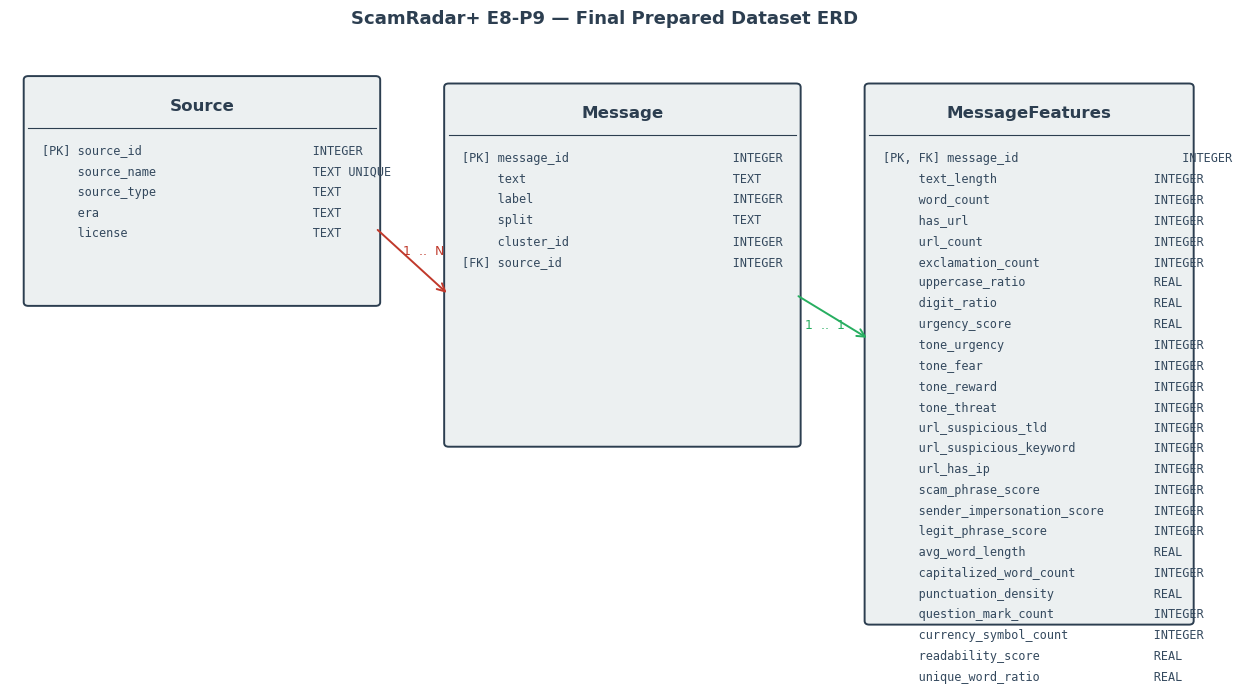

In [28]:
def draw_erd(save_path: Path | None = None):
    fig, ax = plt.subplots(figsize=(13, 7))
    ax.set_xlim(0, 13); ax.set_ylim(0, 8); ax.axis('off')

    def entity(x, y, w, h, title, cols, pk_idx=(), fk_idx=()):
        ax.add_patch(FancyBboxPatch((x, y), w, h,
            boxstyle='round,pad=0.05', linewidth=1.4,
            edgecolor='#2c3e50', facecolor='#ecf0f1'))
        ax.text(x + w/2, y + h - 0.35, title, ha='center', va='center',
                fontsize=12, fontweight='bold', color='#2c3e50')
        ax.plot([x, x + w], [y + h - 0.65, y + h - 0.65],
                color='#2c3e50', linewidth=0.8)
        for i, (col, typ) in enumerate(cols):
            marks = []
            if i in pk_idx: marks.append('PK')
            if i in fk_idx: marks.append('FK')
            prefix = f'[{", ".join(marks)}] ' if marks else '     '
            ax.text(x + 0.15, y + h - 0.95 - i*0.28,
                    f'{prefix}{col:32s} {typ}',
                    ha='left', va='center',
                    fontsize=8.5, family='monospace', color='#34495e')

    entity(0.2, 4.5, 3.8, 3.0, 'Source', [
        ('source_id', 'INTEGER'), ('source_name', 'TEXT UNIQUE'),
        ('source_type', 'TEXT'), ('era', 'TEXT'), ('license', 'TEXT'),
    ], pk_idx=(0,))

    entity(4.8, 2.6, 3.8, 4.8, 'Message', [
        ('message_id', 'INTEGER'), ('text', 'TEXT'), ('label', 'INTEGER'),
        ('split', 'TEXT'), ('cluster_id', 'INTEGER'), ('source_id', 'INTEGER'),
    ], pk_idx=(0,), fk_idx=(5,))

    features = [
        ('message_id',                 'INTEGER'),
        ('text_length',                'INTEGER'),
        ('word_count',                 'INTEGER'),
        ('has_url',                    'INTEGER'),
        ('url_count',                  'INTEGER'),
        ('exclamation_count',          'INTEGER'),
        ('uppercase_ratio',            'REAL'),
        ('digit_ratio',                'REAL'),
        ('urgency_score',              'REAL'),
        ('tone_urgency',               'INTEGER'),
        ('tone_fear',                  'INTEGER'),
        ('tone_reward',                'INTEGER'),
        ('tone_threat',                'INTEGER'),
        ('url_suspicious_tld',         'INTEGER'),
        ('url_suspicious_keyword',     'INTEGER'),
        ('url_has_ip',                 'INTEGER'),
        ('scam_phrase_score',          'INTEGER'),
        ('sender_impersonation_score', 'INTEGER'),
        ('legit_phrase_score',         'INTEGER'),
        ('avg_word_length',            'REAL'),
        ('capitalized_word_count',     'INTEGER'),
        ('punctuation_density',        'REAL'),
        ('question_mark_count',        'INTEGER'),
        ('currency_symbol_count',      'INTEGER'),
        ('readability_score',          'REAL'),
        ('unique_word_ratio',          'REAL'),
    ]
    entity(9.4, 0.2, 3.5, 7.2, 'MessageFeatures', features,
           pk_idx=(0,), fk_idx=(0,))

    ax.add_patch(FancyArrowPatch((4.0, 5.5), (4.8, 4.6),
        arrowstyle='->', mutation_scale=14, color='#c0392b', linewidth=1.4))
    ax.text(4.3, 5.15, '1  ..  N', fontsize=9, color='#c0392b')
    ax.add_patch(FancyArrowPatch((8.6, 4.6), (9.4, 4.0),
        arrowstyle='->', mutation_scale=14, color='#27ae60', linewidth=1.4))
    ax.text(8.7, 4.15, '1  ..  1', fontsize=9, color='#27ae60')

    ax.set_title('ScamRadar+ E8-P9 — Final Prepared Dataset ERD',
                 fontsize=13, fontweight='bold', pad=14, color='#2c3e50')
    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


draw_erd(save_path=REPO_ROOT / 'notebooks' / 'erd.png')

## 14. Final EDA — SQL-driven

Every plot and statistic below comes from a SQL query run against the
database built in Section 10. Pandas is used only for rendering; the
analytical logic is in the SQL.

### 14.1 Class distribution

 label      n   pct label_name
     0 227351 80.19      legit
     1  56150 19.81       scam


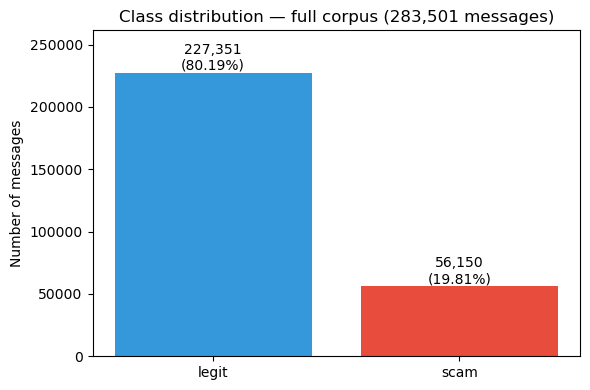

In [29]:
cd = class_distribution()
cd['pct'] = (100 * cd['n'] / cd['n'].sum()).round(2)
cd['label_name'] = cd.label.map({0: 'legit', 1: 'scam'})
print(cd.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(cd.label_name, cd.n, color=['#3498db', '#e74c3c'])
for i, (name, n, pct) in enumerate(zip(cd.label_name, cd.n, cd.pct)):
    ax.text(i, n, f'{n:,}\n({pct}%)', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('Number of messages')
ax.set_title(f'Class distribution — full corpus ({cd.n.sum():,} messages)')
ax.set_ylim(0, cd.n.max() * 1.15)
plt.tight_layout(); plt.show()

           legit   scam  scam_share_%
split                                
external   20364   4477         18.02
test       29378   4352         12.90
train     148169  42971         22.48
val        29440   4350         12.87


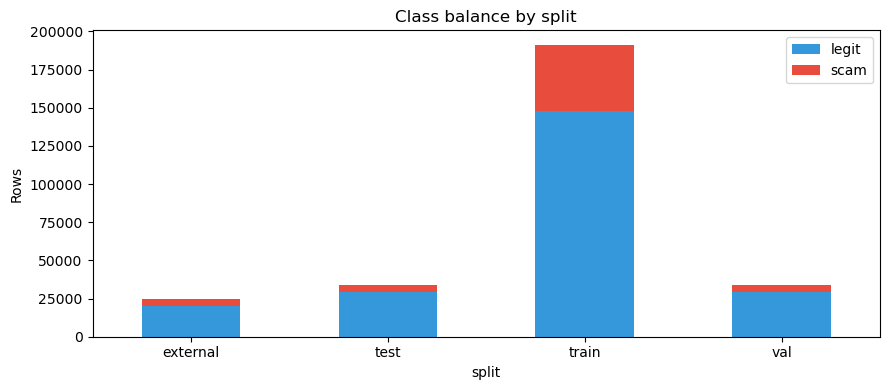

In [30]:
psb = per_split_class_balance()
pivot = psb.pivot(index='split', columns='label', values='n').fillna(0).astype(int)
pivot.columns = ['legit', 'scam']
pivot['scam_share_%'] = (100 * pivot.scam / (pivot.legit + pivot.scam)).round(2)
print(pivot)

fig, ax = plt.subplots(figsize=(9, 4))
pivot[['legit','scam']].plot(kind='bar', stacked=True, ax=ax,
                              color=['#3498db', '#e74c3c'])
ax.set_ylabel('Rows'); ax.set_title('Class balance by split')
ax.set_xticklabels(pivot.index, rotation=0)
plt.tight_layout(); plt.show()

### 14.2 Source composition

                        source_name source_type     era      n
                       multiwoz_v22        real  modern 104663
                        dailydialog        real  modern  52772
               zenodo_champa_ceas08        real  legacy  32516
                   enron_ham_sample        real  legacy  29057
                   emscad_job_scams        real  legacy  15708
               synthetic_e8p6_legit   synthetic  modern  15521
                synthetic_e8p8_scam   synthetic  modern  14670
                sms_spam_collection        real  legacy   4891
zenodo_champa_nigerian_fraud_legacy        real  legacy   3280
                     e5_base_corpus        real unknown   2080
               synthetic_e8p2_legit   synthetic  modern   1978
       zenodo_champa_nazario_legacy        real  legacy   1538
zenodo_champa_nigerian_fraud_modern        real  modern   1504
       zenodo_champa_nazario_modern        real  modern   1303
                synthetic_e8p8_pair   synthetic  modern

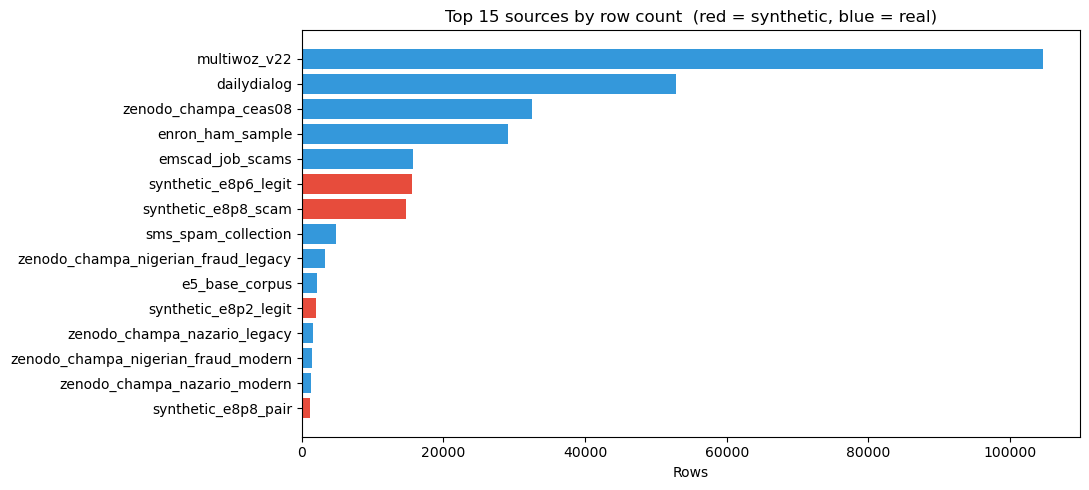

In [31]:
sd = source_distribution().head(15)
print(sd.to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['#e74c3c' if t == 'synthetic' else '#3498db' for t in sd.source_type]
ax.barh(sd.source_name[::-1], sd.n[::-1], color=colors[::-1])
ax.set_xlabel('Rows')
ax.set_title('Top 15 sources by row count  (red = synthetic, blue = real)')
plt.tight_layout(); plt.show()

### 14.3 Message-length distribution by label

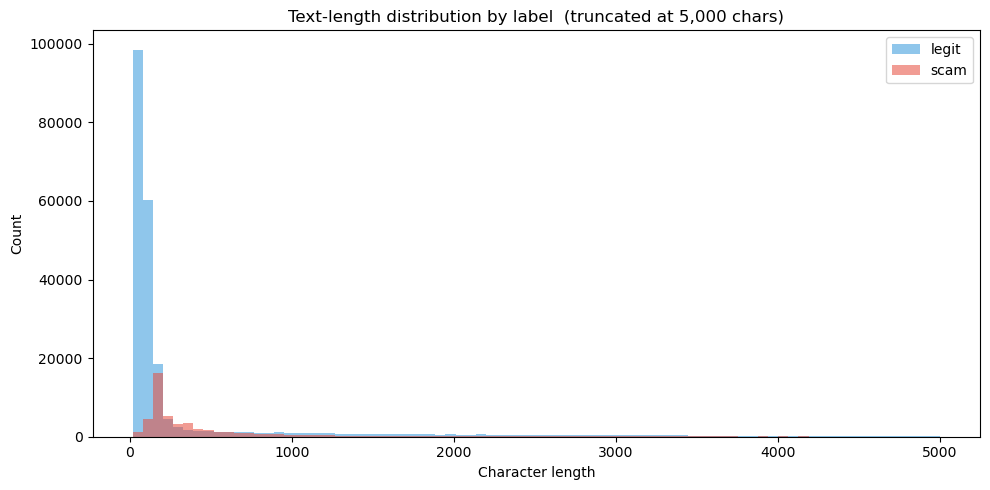

 label      n  mean_len  min_len  max_len
     0 227351     537.0       20   178882
     1  56150     963.0       20  4549399


In [32]:
len_df = pd.read_sql('''
    SELECT m.label, f.text_length
    FROM Message m JOIN MessageFeatures f ON m.message_id = f.message_id
    WHERE f.text_length < 5000
''', conn)

fig, ax = plt.subplots(figsize=(10, 5))
for lab, color, name in [(0, '#3498db', 'legit'), (1, '#e74c3c', 'scam')]:
    subset = len_df[len_df.label == lab].text_length
    ax.hist(subset, bins=80, alpha=0.55, color=color, label=name)
ax.set_xlabel('Character length'); ax.set_ylabel('Count')
ax.set_title('Text-length distribution by label  (truncated at 5,000 chars)')
ax.legend(); plt.tight_layout(); plt.show()

print(length_stats_by_label().to_string(index=False))

### 14.4 Tone-feature means by label

 label  mean_urgency  mean_fear  mean_reward  mean_threat
     0         0.025      0.002        0.001        0.000
     1         0.156      0.032        0.025        0.008


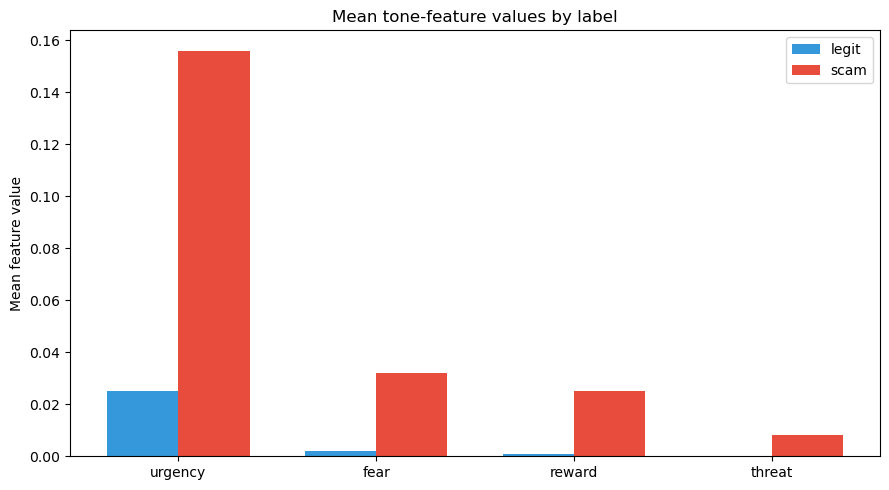

In [33]:
tone_stats = pd.read_sql('''
    SELECT m.label,
           ROUND(AVG(f.tone_urgency), 3) AS mean_urgency,
           ROUND(AVG(f.tone_fear),    3) AS mean_fear,
           ROUND(AVG(f.tone_reward),  3) AS mean_reward,
           ROUND(AVG(f.tone_threat),  3) AS mean_threat
    FROM Message m JOIN MessageFeatures f ON m.message_id = f.message_id
    GROUP BY m.label
''', conn)
print(tone_stats.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
tones = ['urgency', 'fear', 'reward', 'threat']
means_legit = tone_stats[tone_stats.label == 0].iloc[0, 1:].values
means_scam  = tone_stats[tone_stats.label == 1].iloc[0, 1:].values
x = np.arange(len(tones)); w = 0.36
ax.bar(x - w/2, means_legit, w, color='#3498db', label='legit')
ax.bar(x + w/2, means_scam,  w, color='#e74c3c', label='scam')
ax.set_xticks(x); ax.set_xticklabels(tones)
ax.set_ylabel('Mean feature value')
ax.set_title('Mean tone-feature values by label')
ax.legend(); plt.tight_layout(); plt.show()

### 14.5 URL presence by label

 label  with_url  total  pct_with_url label_name
     0     12830 227351          5.64      legit
     1     21977  56150         39.14       scam


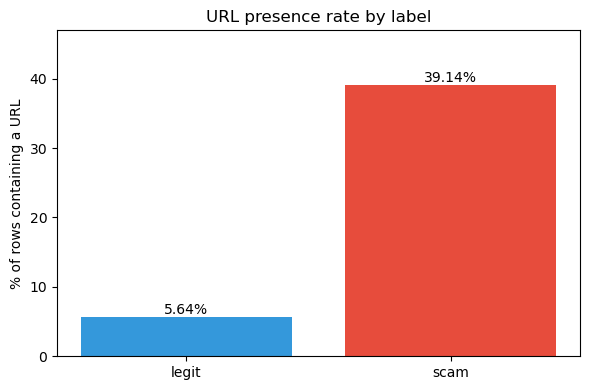

In [34]:
url_pct = has_url_share_by_label()
url_pct['label_name'] = url_pct.label.map({0: 'legit', 1: 'scam'})
print(url_pct.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(url_pct.label_name, url_pct.pct_with_url, color=['#3498db', '#e74c3c'])
for i, pct in enumerate(url_pct.pct_with_url):
    ax.text(i, pct, f'{pct}%', ha='center', va='bottom', fontsize=10)
ax.set_ylabel('% of rows containing a URL')
ax.set_title('URL presence rate by label')
ax.set_ylim(0, max(url_pct.pct_with_url) * 1.2)
plt.tight_layout(); plt.show()

### 14.6 Feature ↔ label correlation

Point-biserial correlation between each numerical feature and the binary
label. Positive → pushes toward SCAM; negative → toward LEGIT.

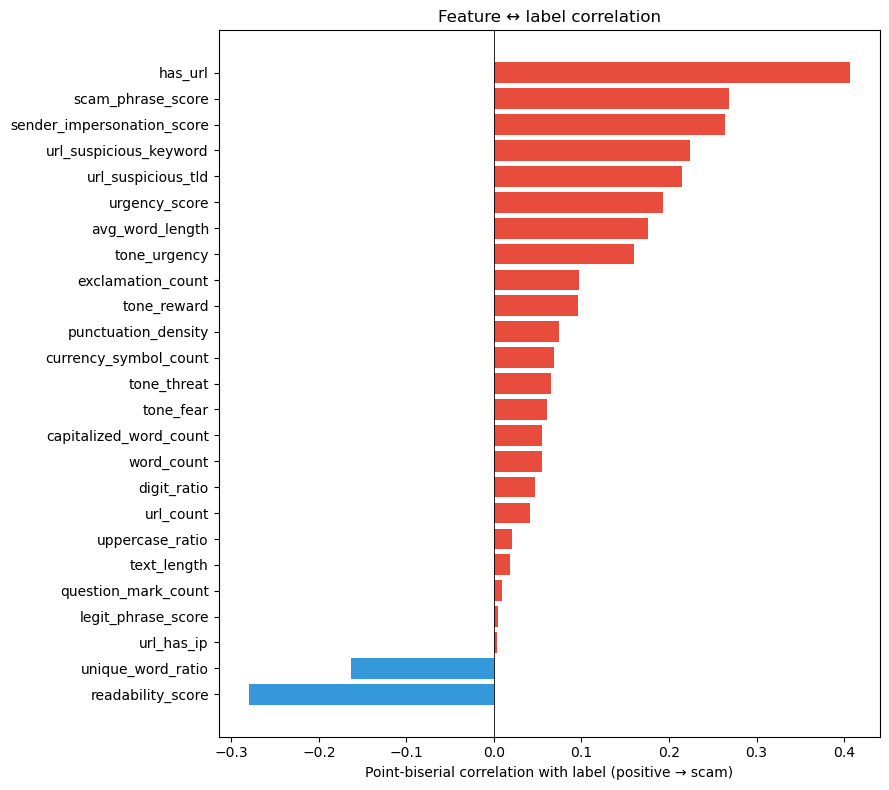

readability_score            -0.280
unique_word_ratio            -0.163
url_has_ip                    0.004
legit_phrase_score            0.005
question_mark_count           0.009
text_length                   0.019
uppercase_ratio               0.021
url_count                     0.042
digit_ratio                   0.046
word_count                    0.054
capitalized_word_count        0.055
tone_fear                     0.061
tone_threat                   0.066
currency_symbol_count         0.068
punctuation_density           0.075
tone_reward                   0.096
exclamation_count             0.098
tone_urgency                  0.160
avg_word_length               0.176
urgency_score                 0.193
url_suspicious_tld            0.215
url_suspicious_keyword        0.224
sender_impersonation_score    0.264
scam_phrase_score             0.268
has_url                       0.407


In [35]:
corr_data = pd.read_sql(f'''
    SELECT m.label, {", ".join(f"f.{c}" for c in FEATURE_COLS)}
    FROM Message m JOIN MessageFeatures f ON m.message_id = f.message_id
''', conn)

corrs = corr_data.corr(numeric_only=True)['label'].drop('label').sort_values()

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors)
ax.axvline(0, color='black', linewidth=0.6)
ax.set_xlabel('Point-biserial correlation with label (positive → scam)')
ax.set_title('Feature ↔ label correlation')
plt.tight_layout(); plt.show()

print(corrs.round(3).to_string())

### 14.7 Statistical tests

Four tests, each answering a specific DP-level question. All contingency
tables and paired samples are pulled from the DB by SQL.

In [36]:
# Test 1: chi-square — class distribution × split
ct = pd.read_sql('''
    SELECT split, label, COUNT(*) AS n FROM Message GROUP BY split, label
''', conn).pivot(index='split', columns='label', values='n').fillna(0).astype(int)
chi2, p, dof, _ = stats.chi2_contingency(ct.values)
print('Test 1 — Chi-square: class × split')
print(f'  H0: label is independent of split')
print(f'  chi2={chi2:.2f}   dof={dof}   p={p:.4g}')
print(f'  → {"reject" if p < 0.05 else "do not reject"} H0 at alpha=0.05')
print(ct)

Test 1 — Chi-square: class × split
  H0: label is independent of split
  chi2=2945.61   dof=3   p=0
  → reject H0 at alpha=0.05
label          0      1
split                  
external   20364   4477
test       29378   4352
train     148169  42971
val        29440   4350


In [37]:
# Test 2: chi-square — has_url × label
ct = pd.read_sql('''
    SELECT f.has_url, m.label, COUNT(*) AS n
    FROM Message m JOIN MessageFeatures f ON m.message_id = f.message_id
    GROUP BY f.has_url, m.label
''', conn).pivot(index='has_url', columns='label', values='n').fillna(0).astype(int)
chi2, p, dof, _ = stats.chi2_contingency(ct.values)
print('Test 2 — Chi-square: has_url × label')
print(f'  H0: URL presence is independent of label')
print(f'  chi2={chi2:.2f}   dof={dof}   p={p:.4g}')
print(f'  → {"reject" if p < 0.05 else "do not reject"} H0 at alpha=0.05')
print(ct)

Test 2 — Chi-square: has_url × label
  H0: URL presence is independent of label
  chi2=46907.32   dof=1   p=0
  → reject H0 at alpha=0.05
label         0      1
has_url               
0        214521  34173
1         12830  21977


In [38]:
# Test 3: Mann-Whitney U — text_length by label
legit = pd.read_sql('''
    SELECT f.text_length FROM Message m
    JOIN MessageFeatures f ON m.message_id = f.message_id
    WHERE m.label = 0
''', conn).text_length.values
scam  = pd.read_sql('''
    SELECT f.text_length FROM Message m
    JOIN MessageFeatures f ON m.message_id = f.message_id
    WHERE m.label = 1
''', conn).text_length.values

u, p = stats.mannwhitneyu(legit, scam, alternative='two-sided')
print('Test 3 — Mann-Whitney U: text_length by label')
print(f'  H0: distributions identical across label')
print(f'  U={u:.2e}   p={p:.4g}   n_legit={len(legit):,}   n_scam={len(scam):,}')
print(f'  medians: legit={int(np.median(legit))}   scam={int(np.median(scam))}')
print(f'  → {"reject" if p < 0.05 else "do not reject"} H0 at alpha=0.05')

Test 3 — Mann-Whitney U: text_length by label
  H0: distributions identical across label
  U=2.66e+09   p=0   n_legit=227,351   n_scam=56,150
  medians: legit=93   scam=283
  → reject H0 at alpha=0.05


In [39]:
# Test 4: Mann-Whitney U — scam_phrase_score by label (one-sided: legit < scam)
legit = pd.read_sql('''
    SELECT f.scam_phrase_score FROM Message m
    JOIN MessageFeatures f ON m.message_id = f.message_id
    WHERE m.label = 0
''', conn).scam_phrase_score.values
scam  = pd.read_sql('''
    SELECT f.scam_phrase_score FROM Message m
    JOIN MessageFeatures f ON m.message_id = f.message_id
    WHERE m.label = 1
''', conn).scam_phrase_score.values

u, p = stats.mannwhitneyu(legit, scam, alternative='less')
print('Test 4 — Mann-Whitney U: scam_phrase_score by label  (one-sided: legit < scam)')
print(f'  U={u:.2e}   p={p:.4g}')
print(f'  means: legit={legit.mean():.3f}   scam={scam.mean():.3f}')
print(f'  → {"reject" if p < 0.05 else "do not reject"} H0 at alpha=0.05')

Test 4 — Mann-Whitney U: scam_phrase_score by label  (one-sided: legit < scam)
  U=5.68e+09   p=0
  means: legit=0.003   scam=0.146
  → reject H0 at alpha=0.05


## 15. Summary

**End-to-end chain proven:**

```
data_understanding.ipynb
   → orchestrates `scamradar acquire`
   → SCAMRADAR2_ROOT/data/raw/canonical.parquet    (DU output = DP input)
   → [this notebook orchestrates the production pipeline, cache-aware]
   → data/interim/e7_p1_features_e8p9.parquet
   → data/final_db/scamradar_e8p9.db
```

**Data Preparation deliverables produced by this notebook:**

- **Relational database** — `data/final_db/scamradar_e8p9.db` (SQLite,
  three tables + FK relationships + three indexes).
- **Insertion code** — Section 11 (visible SQL, bulk `executemany`).
- **Retrieval code** — Section 12 (eight named functions, real SQL, JOINs).
- **ERD** — Section 13 (inline + saved to `notebooks/erd.png`).
- **Final EDA** — Section 14 (descriptive stats for target + features, six
  plots, four statistical tests).

**Nothing in the production pipeline was modified.** Every pipeline stage
is invoked via subprocess or import of existing production code. If any
intermediate artifact is missing, the corresponding stage rebuilds it; if
all are cached, the notebook completes in seconds.

Set `FORCE_REBUILD = True` in Section 0 and re-run All to rebuild every
stage from scratch (approximately 20–30 minutes on first run).

In [40]:
conn.close()
print(f'Closed connection. DB persists at: {DB_PATH}')
print(f'File size: {DB_PATH.stat().st_size / 1e6:.1f} MB')

Closed connection. DB persists at: /Users/ameer/Downloads/ScamRadar/data/final_db/scamradar_e8p9.db
File size: 252.1 MB
